### Sentiment analiza

##### Link do dataseta: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones?resource=download

#### Učitavanje potrebnih biblioteka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import defaultdict
from plotly import subplots
import plotly.graph_objs as go
import plotly.offline as py
nltk.download('wordnet')
import re
import plotly.io as pio
pio.renderers.default = 'notebook'


[nltk_data] Downloading package punkt to /home/nastasija/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/nastasija/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/nastasija/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/nastasija/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#### Učitavanje dataset-a

In [2]:
dataset = pd.read_csv("Amazon_Reviews.csv", index_col=False)

#### Analiza dataset-a

In [3]:
dataset.head()

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [4]:
dataset.describe(include='object')

,Product Name,Brand Name,Reviews
count,413840,348669,413770
unique,4410,384,162490
top,Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...,Samsung,Good
freq,1451,65747,2879


In [5]:
dataset.isna().sum()

Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64

#### Preprocesiranje dataset-a

##### Ekstrakcija potrebnih atributa

In [6]:
filtered_dataset = dataset[['Reviews', 'Rating']].copy()
filtered_dataset.head()

,Reviews,Rating
0,I feel so LUCKY to have found this used (phone...,5
1,"nice phone, nice up grade from my pantach revu...",4
2,Very pleased,5
3,It works good but it goes slow sometimes but i...,4
4,Great phone to replace my lost phone. The only...,4


##### Enkodiranje rating feature-a

In [7]:
def encode_rating(rating: int) -> str:
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"

In [8]:
filtered_dataset['Label'] = filtered_dataset['Rating'].apply(encode_rating) 
filtered_dataset.drop('Rating', axis=1, inplace=True)
print("Unique values of Label: ", filtered_dataset['Label'].unique())
filtered_dataset.head()

Unique values of Label:  ['Positive' 'Negative' 'Neutral']


,Reviews,Label
0,I feel so LUCKY to have found this used (phone...,Positive
1,"nice phone, nice up grade from my pantach revu...",Positive
2,Very pleased,Positive
3,It works good but it goes slow sometimes but i...,Positive
4,Great phone to replace my lost phone. The only...,Positive


##### Uklanjanje nedostajućih vrednosti

In [9]:
print("Dataset shape before dropping: ", filtered_dataset.shape)
filtered_dataset.dropna(inplace=True)
print("Dataset shape after dropping: ", filtered_dataset.shape)

Dataset shape before dropping:  (413840, 2)
Dataset shape after dropping:  (413770, 2)


In [10]:
filtered_dataset.describe()

,Reviews,Label
count,413770,413770
unique,162490,3
top,Good,Positive
freq,2879,284948


In [11]:
non_preprocessed_dataset = filtered_dataset.copy()

##### Čišćenje review-a

In [12]:
def removing_url(review: str) -> str:
    return re.sub(r'http\S+', '', review)

def clean_non_alphanumeric(review: str) -> str:
    return re.sub('[^a-zA-Z]', ' ', review)

def convert_to_lowercase(review: str) -> str:
    return str(review).lower()

def tokenize_text(review_text: str) -> str:
    return word_tokenize(review_text)

In [13]:
filtered_dataset['CleanReviews'] = filtered_dataset['Reviews'].apply(removing_url)
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(clean_non_alphanumeric)
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(convert_to_lowercase)
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(tokenize_text)

In [14]:
filtered_dataset = filtered_dataset.replace('', pd.NA).dropna()
print(filtered_dataset.shape)
filtered_dataset.head()

(413770, 3)


,Reviews,Label,CleanReviews
0,I feel so LUCKY to have found this used (phone...,Positive,"[i, feel, so, lucky, to, have, found, this, us..."
1,"nice phone, nice up grade from my pantach revu...",Positive,"[nice, phone, nice, up, grade, from, my, panta..."
2,Very pleased,Positive,"[very, pleased]"
3,It works good but it goes slow sometimes but i...,Positive,"[it, works, good, but, it, goes, slow, sometim..."
4,Great phone to replace my lost phone. The only...,Positive,"[great, phone, to, replace, my, lost, phone, t..."


##### Uklanjanje engleskih stop reči i lematizacija

In [15]:
def remove_stopwords(token: str) -> list[str]:
    stop_words = set(stopwords.words('english'))
    return [item for item in token if item not in stop_words]

def lemmatization(review_text: str) -> list[str]:
    lemma = WordNetLemmatizer()
    return [lemma.lemmatize(word=token, pos='v') for token in review_text]

In [16]:
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(remove_stopwords)
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(lemmatization)
filtered_dataset.head(15)

,Reviews,Label,CleanReviews
0,I feel so LUCKY to have found this used (phone...,Positive,"[feel, lucky, find, use, phone, us, use, hard,..."
1,"nice phone, nice up grade from my pantach revu...",Positive,"[nice, phone, nice, grade, pantach, revue, cle..."
2,Very pleased,Positive,[please]
3,It works good but it goes slow sometimes but i...,Positive,"[work, good, go, slow, sometimes, good, phone,..."
4,Great phone to replace my lost phone. The only...,Positive,"[great, phone, replace, lose, phone, thing, vo..."
5,I already had a phone with problems... I know ...,Negative,"[already, phone, problems, know, state, use, d..."
6,The charging port was loose. I got that solder...,Negative,"[charge, port, loose, get, solder, need, new, ..."
7,"Phone looks good but wouldn't stay charged, ha...",Negative,"[phone, look, good, stay, charge, buy, new, ba..."
8,I originally was using the Samsung S2 Galaxy f...,Positive,"[originally, use, samsung, galaxy, sprint, wan..."
9,It's battery life is great. It's very responsi...,Neutral,"[battery, life, great, responsive, touch, issu..."


In [17]:
def convert_list_of_tokens_to_string(reviews_list: list) -> str:
    return ' '.join(reviews_list)

In [18]:
filtered_dataset['CleanReviews'] = filtered_dataset['CleanReviews'].apply(convert_list_of_tokens_to_string)

In [19]:
filtered_dataset = filtered_dataset[ filtered_dataset['CleanReviews'].str.len() < 2500]

##### Podela skupa podataka po sentimentu

In [20]:
positive_dataset = filtered_dataset[filtered_dataset['Label'] == 'Positive']
negative_dataset = filtered_dataset[filtered_dataset['Label'] == 'Negative']

print("Len of positive dataset: ", positive_dataset.shape[0])
print("Len of negative dataset: ", negative_dataset.shape[0])

Len of positive dataset:  284369
Len of negative dataset:  96932


In [21]:
reduced_filtered_dataset = filtered_dataset[:2000]
finetuning_reduced_filtered_dataset = filtered_dataset[:10000]

#### EDA

<Axes: ylabel='Rating'>

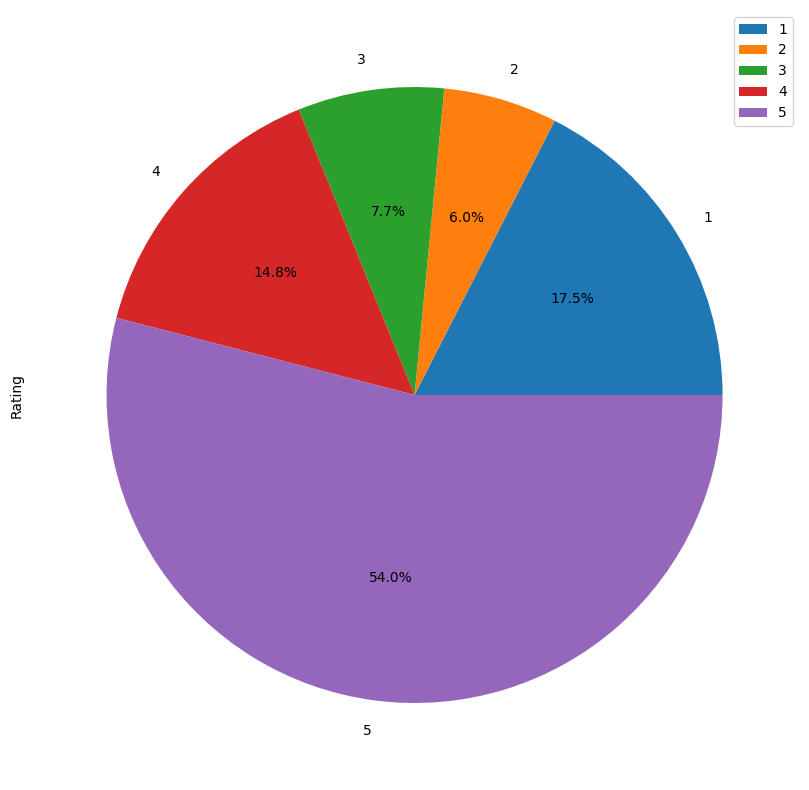

In [22]:
type_counts = dataset['Rating'].value_counts()
df = pd.DataFrame({'Rating': type_counts}, 
                     index = [1, 2, 3, 4, 5])
df.plot.pie(y='Rating', figsize=(10,10), autopct='%1.1f%%')

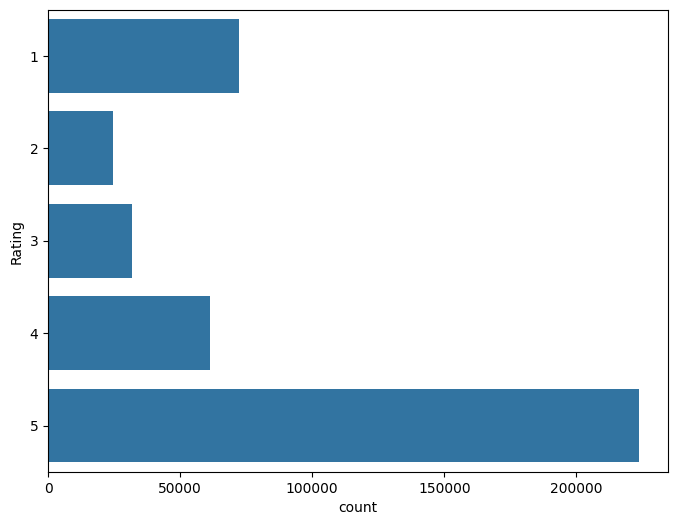

In [23]:
labels = dataset[['Rating']]
plt.figure(figsize=(8,6))
sns.countplot(y='Rating', data=labels)
plt.show()

<Axes: ylabel='Label'>

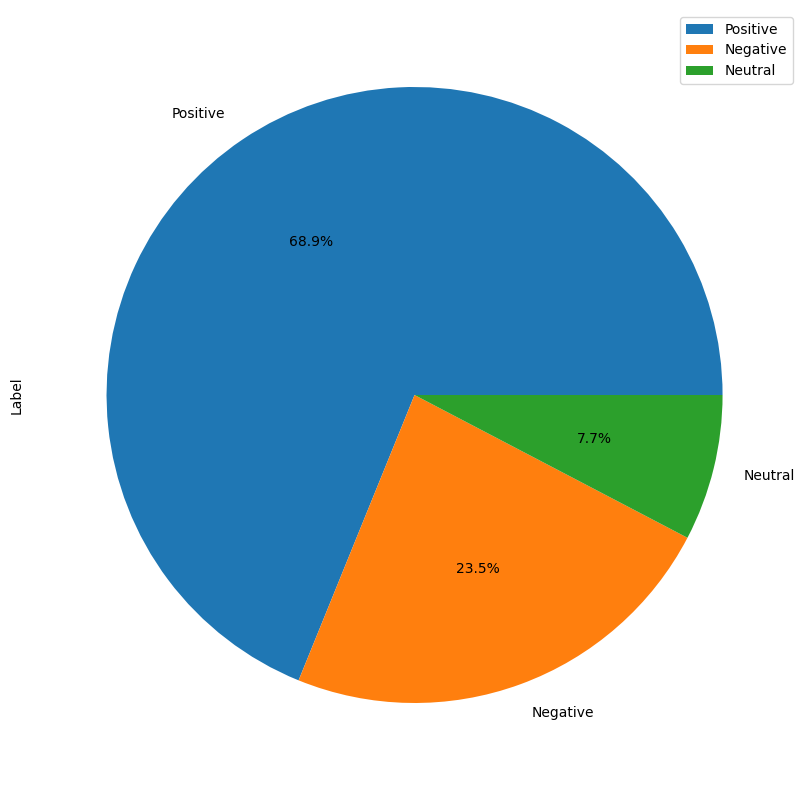

In [24]:
type_counts = filtered_dataset['Label'].value_counts()
df2 = pd.DataFrame({'Label': type_counts}, 
                     index = ['Positive', 'Negative', 'Neutral'])
df2.plot.pie(y='Label', figsize=(10,10), autopct='%1.1f%%')

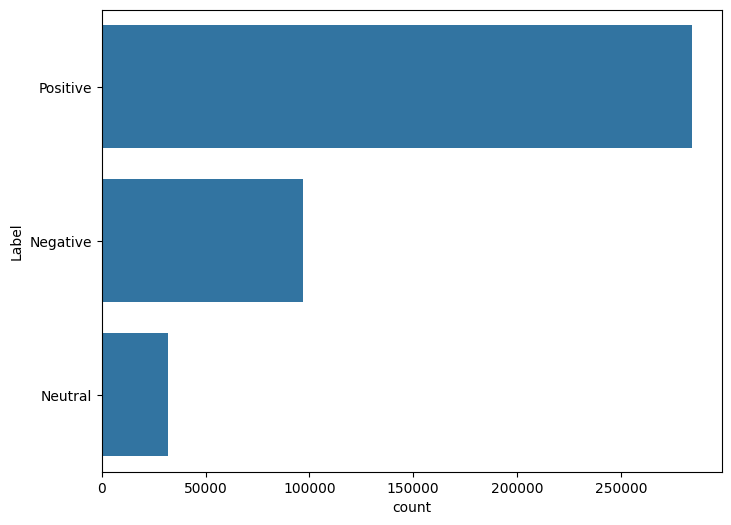

In [25]:
labels = filtered_dataset[['Label']]
plt.figure(figsize=(8,6))
sns.countplot(y='Label', data=labels)
plt.show()

##### WordCloud

In [26]:
def plot_wordcloud(text, mask=None, max_words=200, max_font_size=100, figure_size=(16, 8), 
                   title = None, title_size=40, image_color=False):
    stopwords = set(STOPWORDS)
    more_stopwords = {'one', 'br', 'Po', 'th', 'sayi', 'fo', 'Unknown', 'phone'}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(background_color='black',
                    stopwords = stopwords,
                    max_words = max_words,
                    max_font_size = max_font_size, 
                    random_state = 42,
                    width=800, 
                    height=400,
                    mask = mask)
    wordcloud.generate(str(text))
    
    plt.figure(figsize=figure_size)
    if image_color:
        image_colors = ImageColorGenerator(mask)
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")
        plt.title(title, fontdict={'size': title_size,  
                                  'verticalalignment': 'bottom'})
    else:
        plt.imshow(wordcloud)
        plt.title(title, fontdict={'size': title_size, 'color': 'black', 
                                  'verticalalignment': 'bottom'})
    plt.axis('off')
    plt.tight_layout()  
    

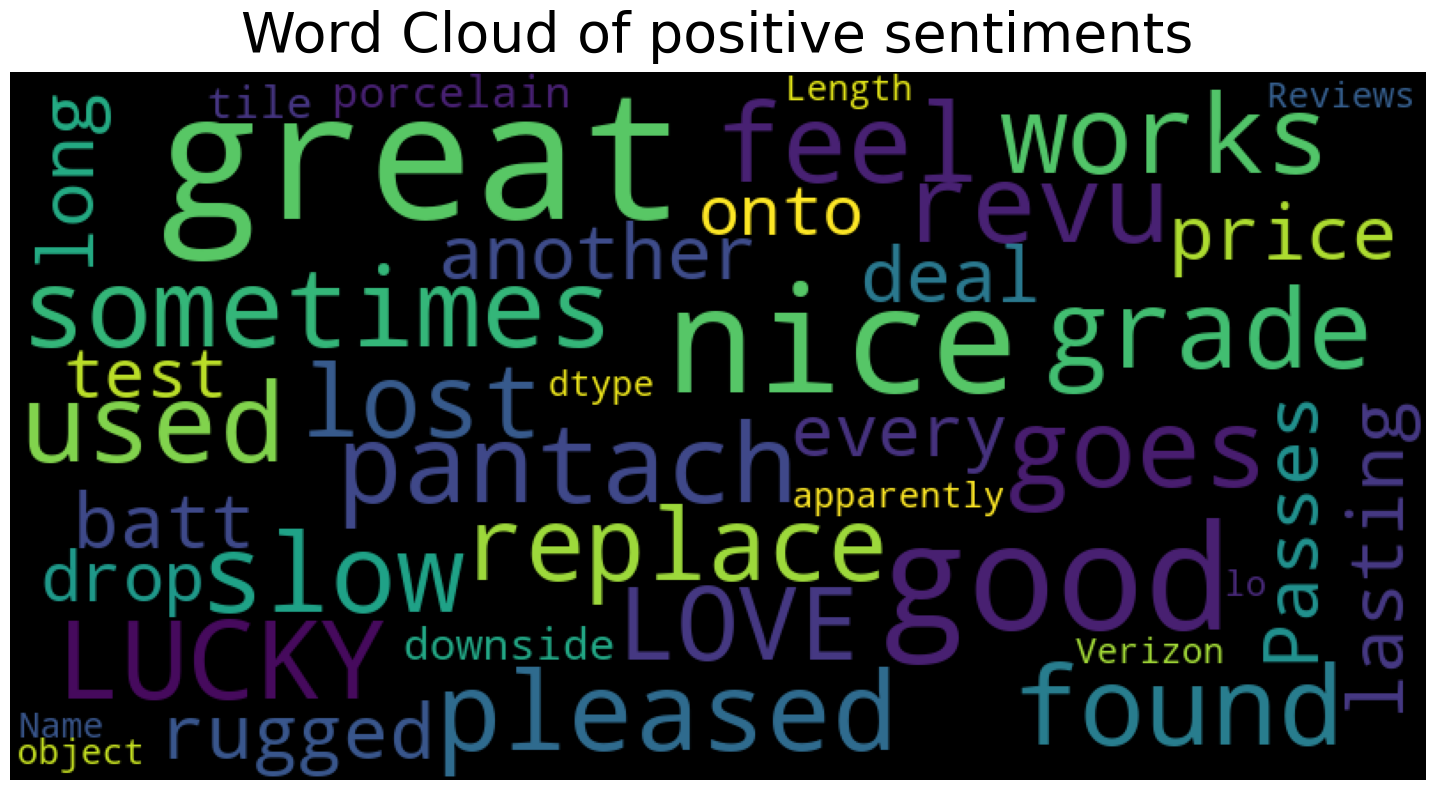

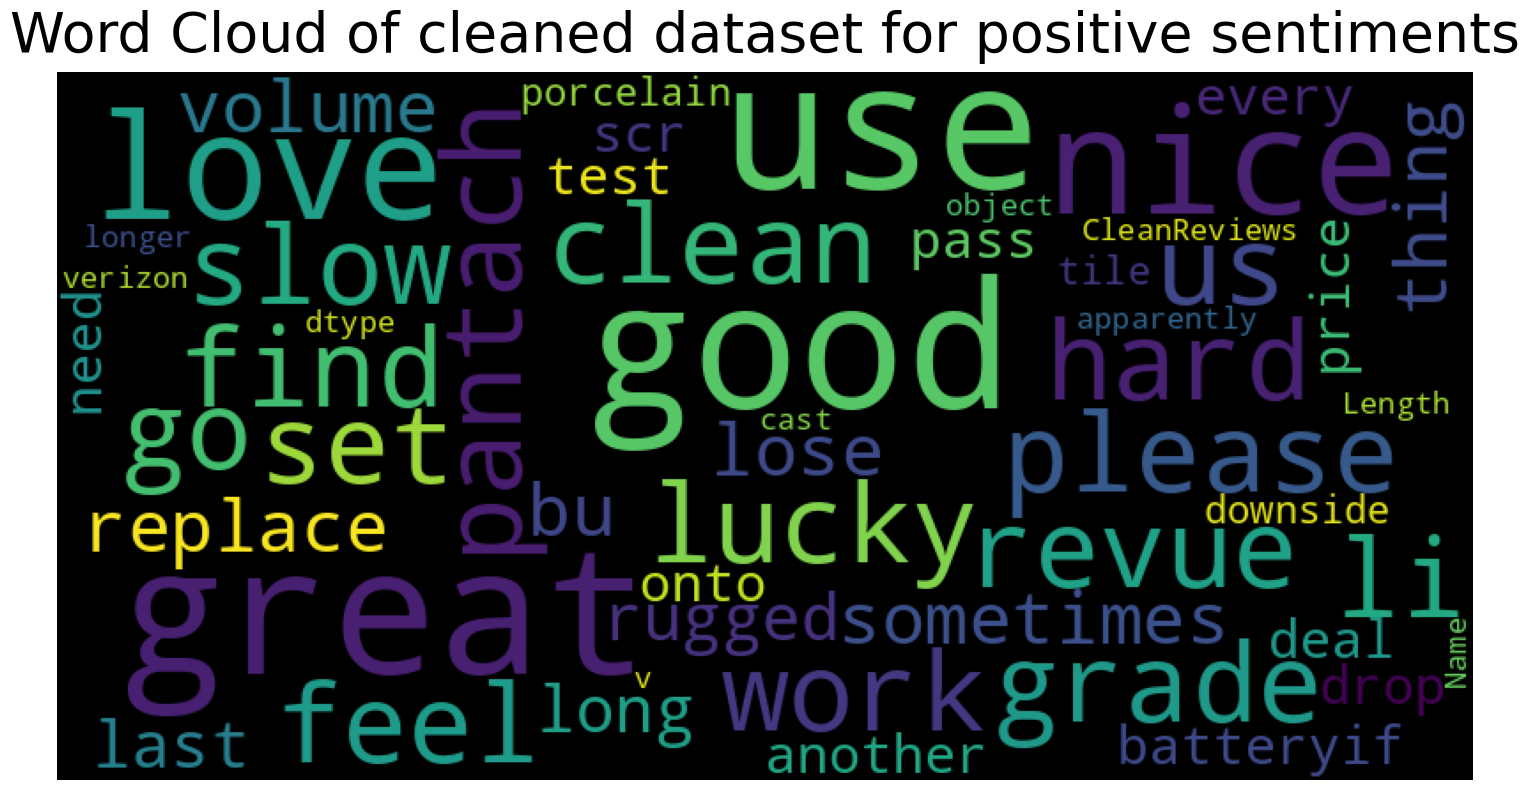

In [27]:
plot_wordcloud(positive_dataset['Reviews'], title="Word Cloud of positive sentiments")
plot_wordcloud(positive_dataset['CleanReviews'], title="Word Cloud of cleaned dataset for positive sentiments")

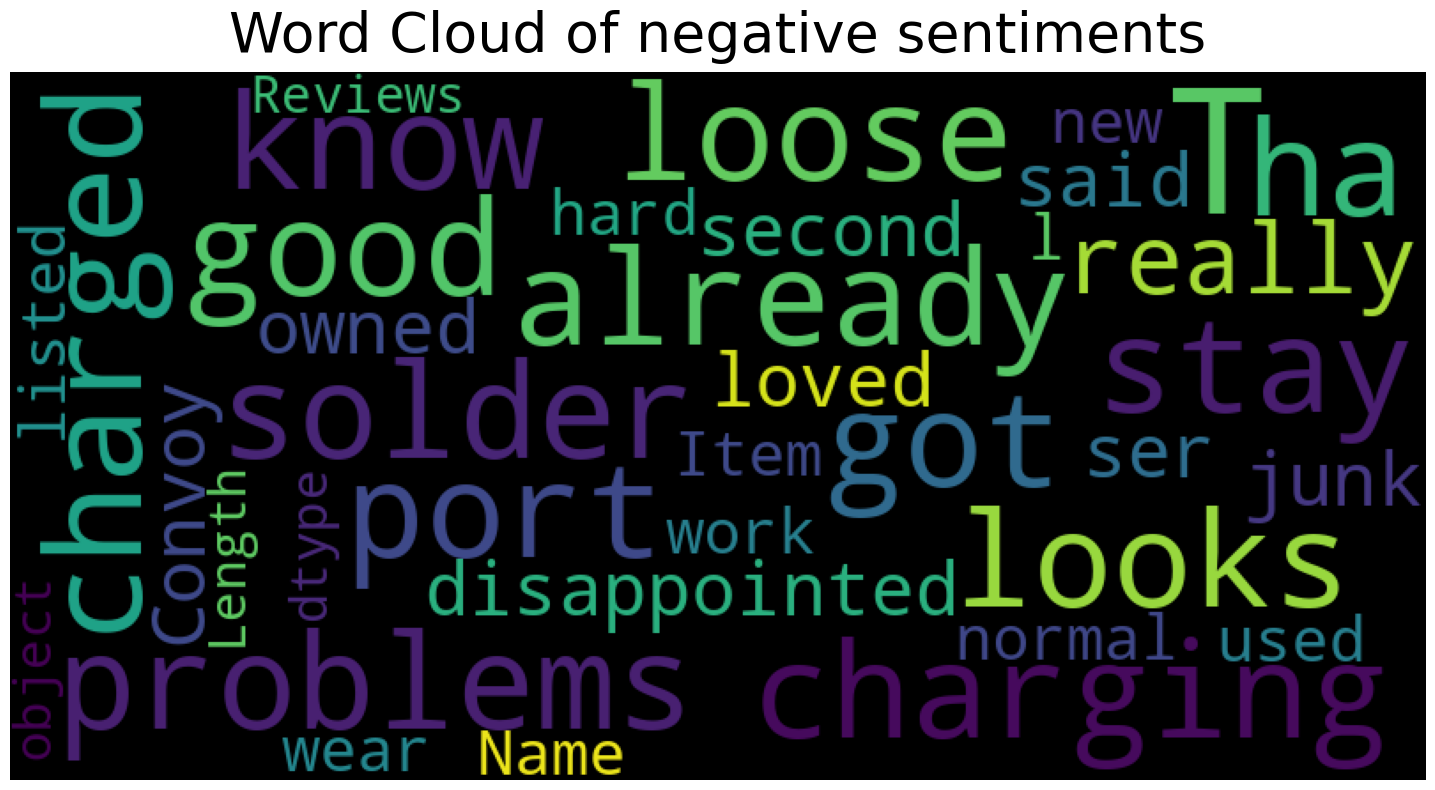

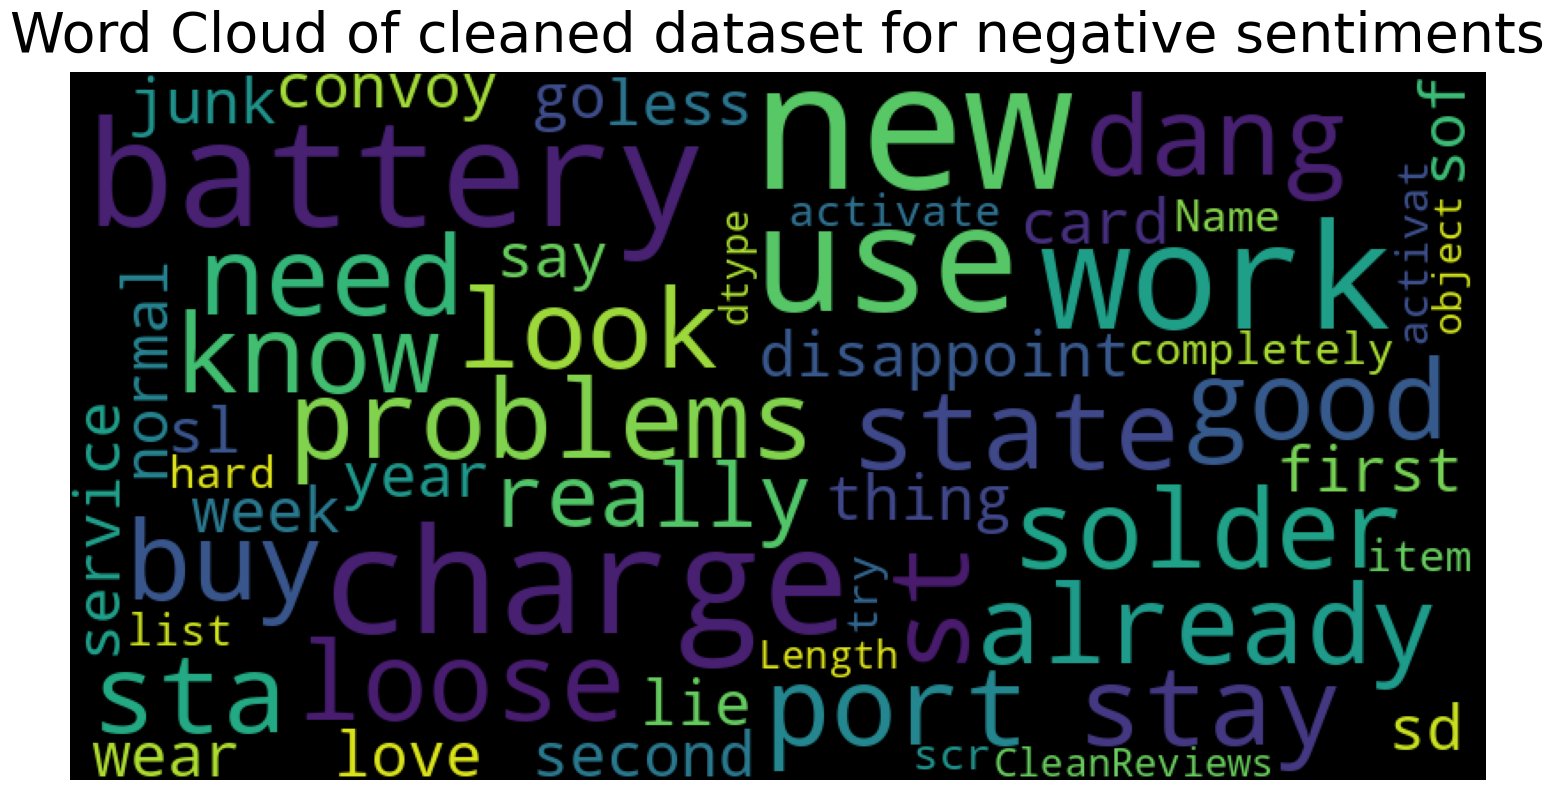

In [28]:
plot_wordcloud(negative_dataset['Reviews'], title="Word Cloud of negative sentiments")
plot_wordcloud(negative_dataset['CleanReviews'], title="Word Cloud of cleaned dataset for negative sentiments")

##### Analiza frekvencije reči i izraza u pozitivnim i negativnim recenzijama (1-grami, 2-grami i 3-grami)

In [29]:
def generate_ngrams(text, n_gram=1):
    token = [token for token in text.lower().split(" ") if token != "" if token not in STOPWORDS]
    ngrams = zip(*[token[i:] for i in range(n_gram)])
    return [" ".join(ngram) for ngram in ngrams]

def horizontal_bar_chart(df, color):
    trace = go.Bar(
        y=df["word"].values[::-1],
        x=df["wordcount"].values[::-1],
        showlegend=False,
        orientation = 'h',
        marker=dict(
            color=color,
        ),
    )
    return trace

common_words = ['phone', 'phone.', 'phone,', 'will', 'one', 'screen', 'battery', 'even', 'use', 'it.']

freq_dict = defaultdict(int)
for sent in positive_dataset["CleanReviews"]:
    for word in generate_ngrams(sent):
        if word not in common_words:
            freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'blue')

freq_dict = defaultdict(int)
for sent in negative_dataset["CleanReviews"]:
    for word in generate_ngrams(sent):
        if word not in common_words:
            freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'blue')

fig = subplots.make_subplots(rows=1, cols=2, vertical_spacing=0.04,
                          subplot_titles=["Frequent words of positive reviews", 
                                          "Frequent words of negative reviews"])
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height=1200, width=900, paper_bgcolor='rgb(233,233,233)', title="Word Count Plots")
fig.show() 

In [30]:
freq_dict = defaultdict(int)
for sent in positive_dataset["CleanReviews"]:
    for word in generate_ngrams(sent,2):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'orange')


freq_dict = defaultdict(int)
for sent in negative_dataset["CleanReviews"]:
    for word in generate_ngrams(sent,2):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'orange')

fig = subplots.make_subplots(rows=1, cols=2, vertical_spacing=0.04,horizontal_spacing=0.15,
                          subplot_titles=["Frequent bigrams of positive reviews", 
                                          "Frequent bigrams of negative reviews"])
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height=1200, width=900, paper_bgcolor='rgb(233,233,233)', title="Bigram Count Plots")
fig.show()

In [31]:
freq_dict = defaultdict(int)
for sent in positive_dataset["CleanReviews"]:
    for word in generate_ngrams(sent,3):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace0 = horizontal_bar_chart(fd_sorted.head(50), 'orange')


freq_dict = defaultdict(int)
for sent in negative_dataset["CleanReviews"]:
    for word in generate_ngrams(sent,3):
        freq_dict[word] += 1
fd_sorted = pd.DataFrame(sorted(freq_dict.items(), key=lambda x: x[1])[::-1])
fd_sorted.columns = ["word", "wordcount"]
trace1 = horizontal_bar_chart(fd_sorted.head(50), 'orange')

fig = subplots.make_subplots(rows=1, cols=2, vertical_spacing=0.04,horizontal_spacing=0.15,
                          subplot_titles=["Frequent bigrams of positive reviews", 
                                          "Frequent bigrams of negative reviews"])
fig.append_trace(trace0, 1, 1)
fig.append_trace(trace1, 1, 2)
fig['layout'].update(height=1200, width=1200, paper_bgcolor='rgb(233,233,233)', title="Bigram Count Plots")
fig.show()

### Trening

#### Transformacija teksta pomoću Bag of Words i TF-IDF pristupa

##### Uključuje:

Transformaciju teksta metodom Bag of Words (BoW)

Transformaciju teksta metodom TF-IDF (Term Frequency – Inverse Document Frequency)

Treniranje klasifikacionih algoritama na dobijenim reprezentacijama teksta

In [32]:
training_data, test_data = train_test_split(finetuning_reduced_filtered_dataset, train_size = 0.7, random_state=42)

#### Reprezentacije sa 1-gramima

##### Reprezentacija 1-grama pomoću Bag of Words transformacije

In [33]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

bow_vectorizer = CountVectorizer(lowercase=False)

X = bow_vectorizer.fit_transform(training_data['CleanReviews'][:5]) 
pd.DataFrame(X.toarray(), columns=bow_vectorizer.get_feature_names_out())

,acurate,align,allow,around,arrive,average,base,battery,bite,bounce,...,tray,try,type,typically,units,use,user,well,work,yes
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,1,1,1,0,1,0,1,0,1,...,1,1,1,1,0,1,1,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,3,1,0,...,0,0,0,0,1,0,0,2,2,1


##### Reprezentacija 1-grama korišćenjem TF-IDF transformacije nad rezultatima Bag of Words transformacije

In [34]:
tfidf_transform = TfidfTransformer(norm=None)
X = tfidf_transform.fit_transform(X)
pd.DataFrame(X.toarray(), columns=bow_vectorizer.get_feature_names_out())

,acurate,align,allow,around,arrive,average,base,battery,bite,bounce,...,tray,try,type,typically,units,use,user,well,work,yes
0,0.000000,0.000000,0.000000,0.000000,1.693147,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.405465,0.000000
1,0.000000,2.098612,2.098612,2.098612,0.000000,2.098612,0.000000,1.693147,0.000000,2.098612,...,2.098612,2.098612,2.098612,2.098612,0.000000,2.098612,2.098612,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,1.693147,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.405465,0.000000
3,2.098612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.098612,5.079442,2.098612,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.098612,0.000000,0.000000,4.197225,2.810930,2.098612


##### Reprezentacija 1-grama pomoću TfIdfVectorizer-a bez korišćenja IDF dela

In [35]:
vectorizer = TfidfVectorizer(use_idf=False) 
X = vectorizer.fit_transform(training_data['CleanReviews'][:5]) 
pd.DataFrame(X.toarray(), columns=bow_vectorizer.get_feature_names_out())

,acurate,align,allow,around,arrive,average,base,battery,bite,bounce,...,tray,try,type,typically,units,use,user,well,work,yes
0,0.000000,0.000000,0.000000,0.000000,0.25000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000
1,0.000000,0.108465,0.108465,0.108465,0.00000,0.108465,0.000000,0.108465,0.000000,0.108465,...,0.108465,0.108465,0.108465,0.108465,0.000000,0.108465,0.108465,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.57735,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.577350,0.000000
3,0.447214,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.141421,0.424264,0.141421,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.141421,0.000000,0.000000,0.282843,0.282843,0.141421


##### Reprezentacija 1-grama pomoću TfIdfVectorizer-a sa uključenim IDF delom

In [36]:
vectorizer = TfidfVectorizer() 
X = vectorizer.fit_transform(training_data['CleanReviews'][:5]) 
pd.DataFrame(X.toarray(), columns=bow_vectorizer.get_feature_names_out())

,acurate,align,allow,around,arrive,average,base,battery,bite,bounce,...,tray,try,type,typically,units,use,user,well,work,yes
0,0.000000,0.000000,0.000000,0.000000,0.214109,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.177730,0.00000
1,0.000000,0.109271,0.109271,0.109271,0.000000,0.109271,0.00000,0.088160,0.00000,0.109271,...,0.109271,0.109271,0.109271,0.109271,0.00000,0.109271,0.109271,0.000000,0.000000,0.00000
2,0.000000,0.000000,0.000000,0.000000,0.556816,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.462208,0.00000
3,0.447214,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.15179,0.367389,0.15179,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.15179,0.000000,0.000000,0.303579,0.203310,0.15179


#### Priprema podataka

##### CountVectorizer

In [37]:
bow_transform = CountVectorizer(lowercase=False) 
X_tr_bow = bow_transform.fit_transform(training_data['CleanReviews'])
y_tr = training_data['Label']

y_bow_transform = CountVectorizer(lowercase=False) 

y_tr_transformed_using_bow = y_bow_transform.fit_transform(training_data['Label'])

print("Shape of X_tr_bow: ", X_tr_bow.shape)
print("Shape of y_tr: ", y_tr.shape)

print("len(bow_transform.vocabulary_): ", len(bow_transform.vocabulary_))

X_te_bow = bow_transform.transform(test_data['CleanReviews'])
y_te = test_data['Label']

y_te_transformed_using_bow = y_bow_transform.transform(test_data['Label'])

print("Shape of X_te_bow: ", X_te_bow.shape)
print("Shape of y_te: ", y_te.shape)

print("Shape of y_tr_transformed_using_bow: ", y_tr_transformed_using_bow.shape)
print("Shape of y_te_transformed_using_bow: ", y_te_transformed_using_bow.shape)


Shape of X_tr_bow:  (7000, 6442)
Shape of y_tr:  (7000,)
len(bow_transform.vocabulary_):  6442
Shape of X_te_bow:  (3000, 6442)
Shape of y_te:  (3000,)
Shape of y_tr_transformed_using_bow:  (7000, 3)
Shape of y_te_transformed_using_bow:  (3000, 3)


##### TfidfTransformer

In [38]:
tfidf_transform = TfidfTransformer(norm=None)
X_tr_tfidf = tfidf_transform.fit_transform(X_tr_bow)
X_te_tfidf = tfidf_transform.transform(X_te_bow)

y_tfidf_transform = TfidfTransformer(norm=None)

y_tr_transformed_using_TfIdfTransformer = y_tfidf_transform.fit_transform(y_tr_transformed_using_bow)
y_te_transformed_using_TfIdfTransformer = y_tfidf_transform.transform(y_te_transformed_using_bow)

print("Shape of X_tr_tfidf: ", X_tr_tfidf.shape)
print("Shape of X_te_tfidf: ", X_te_tfidf.shape)

print("Shape of y_tr_transformed_using_TfIdfTransformer: ", y_tr_transformed_using_TfIdfTransformer.shape)
print("Shape of y_te_transformed_using_TfIdfTransformer: ", y_te_transformed_using_TfIdfTransformer.shape)

Shape of X_tr_tfidf:  (7000, 6442)
Shape of X_te_tfidf:  (3000, 6442)
Shape of y_tr_transformed_using_TfIdfTransformer:  (7000, 3)
Shape of y_te_transformed_using_TfIdfTransformer:  (3000, 3)


##### TfidfVectorizer

In [39]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf_tr = tfidf_vectorizer.fit_transform(training_data['CleanReviews'])
X_tfidf_te = tfidf_vectorizer.transform(test_data['CleanReviews'])

y_tfidf_vectorizer = TfidfVectorizer()
y_tr_transformed_using_TfidfVectorizer = y_tfidf_vectorizer.fit_transform(training_data['Label'])
y_te_transformed_using_TfidfVectorizer = y_tfidf_vectorizer.transform(test_data['Label'])

print("Shape of X_tfidf_tr: ", X_tfidf_tr.shape)
print("Shape of X_tfidf_te: ", X_tfidf_te.shape)

print("Shape of y_tr_transformed_using_TfidfVectorizer: ", y_tr_transformed_using_TfidfVectorizer.shape)
print("Shape of y_te_transformed_using_TfidfVectorizer: ", y_te_transformed_using_TfidfVectorizer.shape)

Shape of X_tfidf_tr:  (7000, 6442)
Shape of X_tfidf_te:  (3000, 6442)
Shape of y_tr_transformed_using_TfidfVectorizer:  (7000, 3)
Shape of y_te_transformed_using_TfidfVectorizer:  (3000, 3)


##### Klasifikacioni algoritmi koji koriste 1-gram vektorizatore

In [42]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

def simple_logistic_classify(model, model_name, X_tr, y_tr, X_test, y_test, description):

    model = model.fit(X_tr, y_tr)

    data_table=pd.DataFrame(columns=['model', 'accuracy'])
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy: {}".format(accuracy))
    print("Classification report :")
    print(classification_report(y_test, y_pred))

    mat = confusion_matrix(y_test, y_pred, labels=y_test.unique())
    sns.heatmap(mat.T, square = True, annot=True, fmt = "d", xticklabels=y_test.unique(), yticklabels=y_test.unique())
    plt.xlabel("true labels")
    plt.ylabel("predicted label")
    plt.show()
    print('*' * 50)
    num_rows = data_table.shape[0]
    data_table.loc[num_rows+1] = [model_name, accuracy]

    return data_table

In [43]:
BOW_METHOD_STRING = "bow"
TF_IDF_TRANSFORMER_METHOD_STRING = "tf-idf-transformer"
TF_IDF_VECTORIZER_METHOD_STRING = "tf-idf-vectorizer"

##### Logistic Regression

Accuracy: 0.8783333333333333
Classification report :
              precision    recall  f1-score   support

    Negative       0.87      0.84      0.85       852
     Neutral       0.69      0.41      0.51       236
    Positive       0.89      0.96      0.92      1912

    accuracy                           0.88      3000
   macro avg       0.82      0.73      0.76      3000
weighted avg       0.87      0.88      0.87      3000



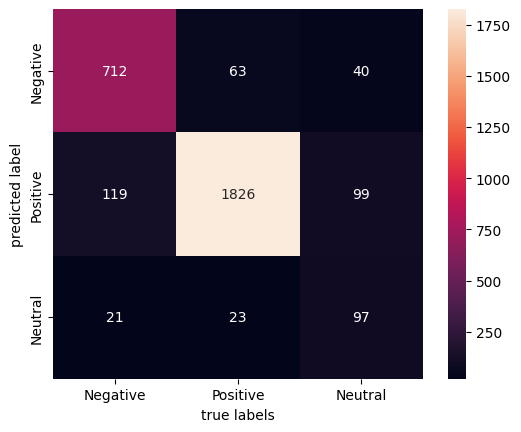

**************************************************
Accuracy: 0.8836666666666667
Classification report :
              precision    recall  f1-score   support

    Negative       0.88      0.83      0.86       852
     Neutral       0.62      0.59      0.61       236
    Positive       0.91      0.94      0.93      1912

    accuracy                           0.88      3000
   macro avg       0.81      0.79      0.80      3000
weighted avg       0.88      0.88      0.88      3000



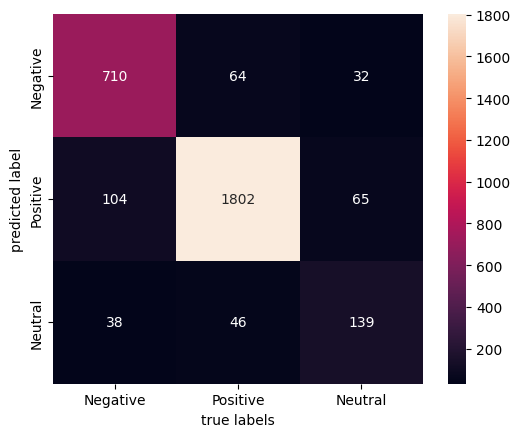

**************************************************
Accuracy: 0.8543333333333333
Classification report :
              precision    recall  f1-score   support

    Negative       0.84      0.81      0.83       852
     Neutral       0.76      0.12      0.21       236
    Positive       0.86      0.96      0.91      1912

    accuracy                           0.85      3000
   macro avg       0.82      0.63      0.65      3000
weighted avg       0.85      0.85      0.83      3000



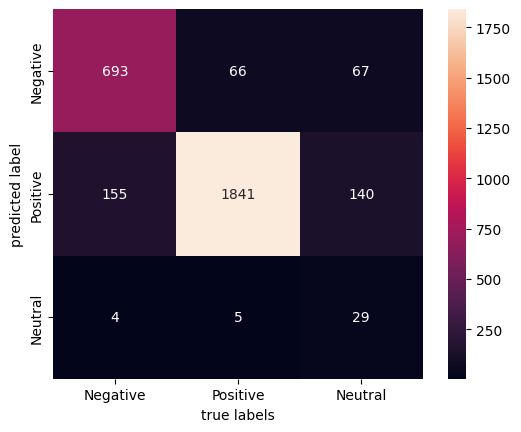

**************************************************


,model,accuracy
0,LogisticRegression_1_gram_bow,0.878333
1,LogisticRegression_1_gram_tf-idf-transformer,0.883667
2,LogisticRegression_1_gram_tf-idf-vectorizer,0.854333


In [44]:
from sklearn.linear_model import LogisticRegression

model_name = "LogisticRegression_1_gram"
model = LogisticRegression(max_iter=500) 

dataframe_bow = simple_logistic_classify(model, f'{model_name}_{BOW_METHOD_STRING}', X_tr_bow, y_tr, X_te_bow, y_te, BOW_METHOD_STRING)
dataframe_tfidf_transformer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_TRANSFORMER_METHOD_STRING}', X_tr_tfidf, y_tr, X_te_tfidf, y_te, TF_IDF_TRANSFORMER_METHOD_STRING)
dataframe_tfidf_vectorizer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_VECTORIZER_METHOD_STRING}', X_tfidf_tr, y_tr, X_tfidf_te, y_te, TF_IDF_VECTORIZER_METHOD_STRING)

data_table_logistic_regression_1_gram = pd.concat([dataframe_bow, dataframe_tfidf_transformer, dataframe_tfidf_vectorizer], ignore_index=True)
data_table_logistic_regression_1_gram

##### Multinomial Naive Bayes

Accuracy: 0.8446666666666667
Classification report :
              precision    recall  f1-score   support

    Negative       0.83      0.79      0.81       852
     Neutral       0.60      0.14      0.23       236
    Positive       0.86      0.95      0.90      1912

    accuracy                           0.84      3000
   macro avg       0.76      0.63      0.65      3000
weighted avg       0.83      0.84      0.82      3000



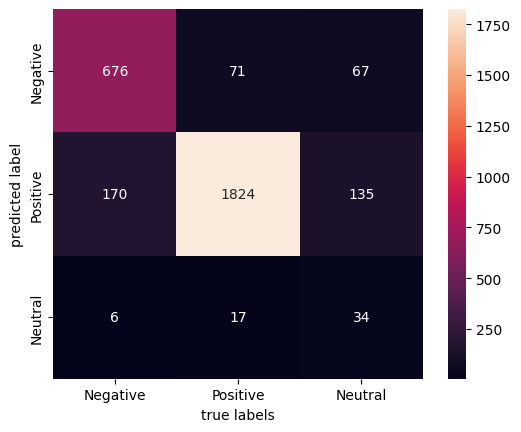

**************************************************
Accuracy: 0.827
Classification report :
              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80       852
     Neutral       0.41      0.51      0.46       236
    Positive       0.90      0.88      0.89      1912

    accuracy                           0.83      3000
   macro avg       0.71      0.73      0.71      3000
weighted avg       0.84      0.83      0.83      3000



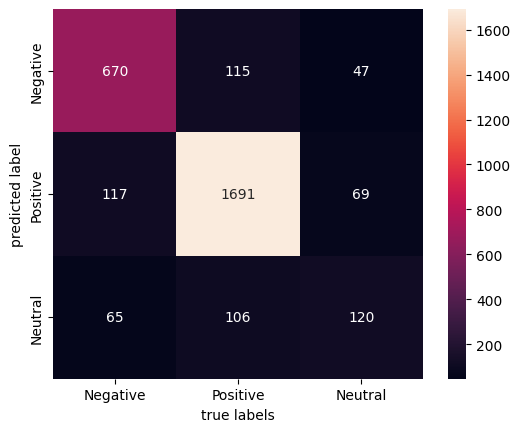

**************************************************
Accuracy: 0.7993333333333333
Classification report :
              precision    recall  f1-score   support

    Negative       0.91      0.59      0.71       852
     Neutral       0.00      0.00      0.00       236
    Positive       0.77      0.99      0.87      1912

    accuracy                           0.80      3000
   macro avg       0.56      0.53      0.53      3000
weighted avg       0.75      0.80      0.76      3000



/home/nastasija/Desktop/DeepLearning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/nastasija/Desktop/DeepLearning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/nastasija/Desktop/DeepLearning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



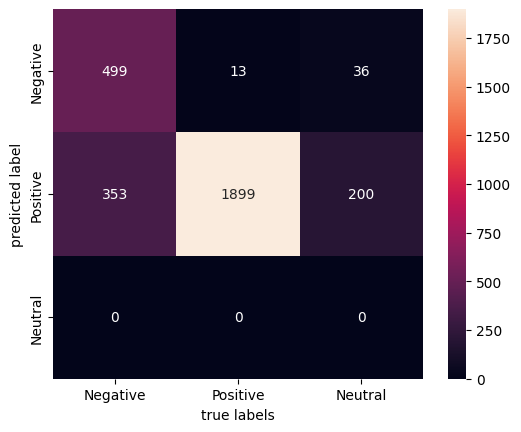

**************************************************


In [45]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model_name = "MultinomialNB_1_gram"

dataframe_bow = simple_logistic_classify(model, f'{model_name}_{BOW_METHOD_STRING}', X_tr_bow, y_tr, X_te_bow, y_te, BOW_METHOD_STRING)
dataframe_tfidf_transformer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_TRANSFORMER_METHOD_STRING}', X_tr_tfidf, y_tr, X_te_tfidf, y_te, TF_IDF_TRANSFORMER_METHOD_STRING)
dataframe_tfidf_vectorizer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_VECTORIZER_METHOD_STRING}', X_tfidf_tr, y_tr, X_tfidf_te, y_te, TF_IDF_VECTORIZER_METHOD_STRING)

data_table_naive_bayes_1_gram = pd.concat([dataframe_bow, dataframe_tfidf_transformer, dataframe_tfidf_vectorizer], ignore_index=True)

##### Random Forest

Accuracy: 0.897
Classification report :
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87       852
     Neutral       0.94      0.47      0.63       236
    Positive       0.90      0.97      0.93      1912

    accuracy                           0.90      3000
   macro avg       0.91      0.77      0.81      3000
weighted avg       0.90      0.90      0.89      3000



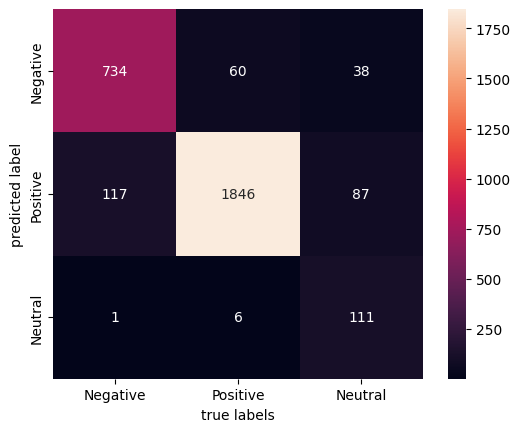

**************************************************
Accuracy: 0.8966666666666666
Classification report :
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87       852
     Neutral       0.94      0.47      0.63       236
    Positive       0.90      0.96      0.93      1912

    accuracy                           0.90      3000
   macro avg       0.91      0.77      0.81      3000
weighted avg       0.90      0.90      0.89      3000



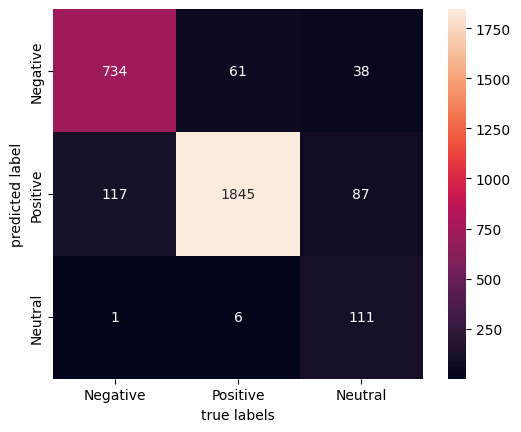

**************************************************
Accuracy: 0.8983333333333333
Classification report :
              precision    recall  f1-score   support

    Negative       0.89      0.85      0.87       852
     Neutral       0.97      0.47      0.64       236
    Positive       0.90      0.97      0.93      1912

    accuracy                           0.90      3000
   macro avg       0.92      0.77      0.81      3000
weighted avg       0.90      0.90      0.89      3000



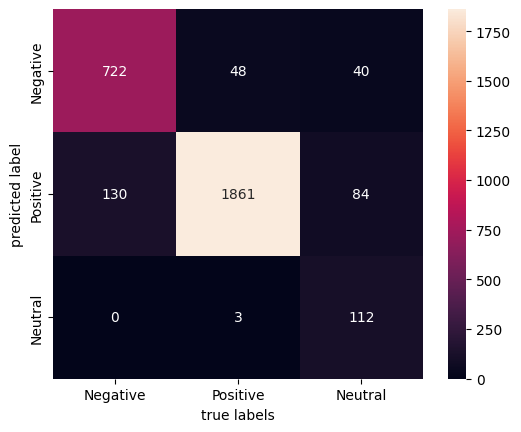

**************************************************


In [46]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model_name = "RandomForestClassifier_1_gram"

dataframe_bow = simple_logistic_classify(model, f'{model_name}_{BOW_METHOD_STRING}', X_tr_bow, y_tr, X_te_bow, y_te, BOW_METHOD_STRING)
dataframe_tfidf_transformer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_TRANSFORMER_METHOD_STRING}', X_tr_tfidf, y_tr, X_te_tfidf, y_te, TF_IDF_TRANSFORMER_METHOD_STRING)
dataframe_tfidf_vectorizer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_VECTORIZER_METHOD_STRING}', X_tfidf_tr, y_tr, X_tfidf_te, y_te, TF_IDF_VECTORIZER_METHOD_STRING)

data_table_rfc_1_gram = pd.concat([dataframe_bow, dataframe_tfidf_transformer, dataframe_tfidf_vectorizer], ignore_index=True)

##### Support Vector Machine

Accuracy: 0.875
Classification report :
              precision    recall  f1-score   support

    Negative       0.86      0.83      0.85       852
     Neutral       0.63      0.47      0.54       236
    Positive       0.90      0.94      0.92      1912

    accuracy                           0.88      3000
   macro avg       0.80      0.75      0.77      3000
weighted avg       0.87      0.88      0.87      3000



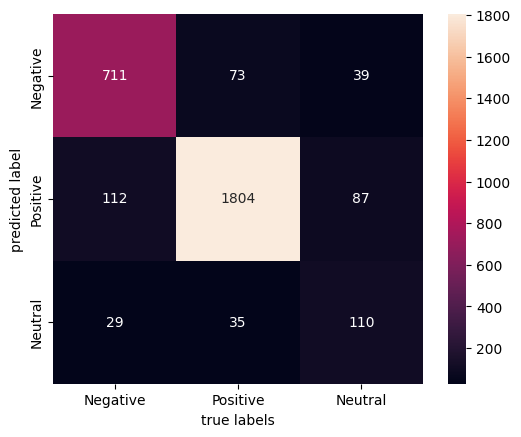

**************************************************
Accuracy: 0.8673333333333333
Classification report :
              precision    recall  f1-score   support

    Negative       0.83      0.83      0.83       852
     Neutral       0.59      0.58      0.58       236
    Positive       0.92      0.92      0.92      1912

    accuracy                           0.87      3000
   macro avg       0.78      0.78      0.78      3000
weighted avg       0.87      0.87      0.87      3000



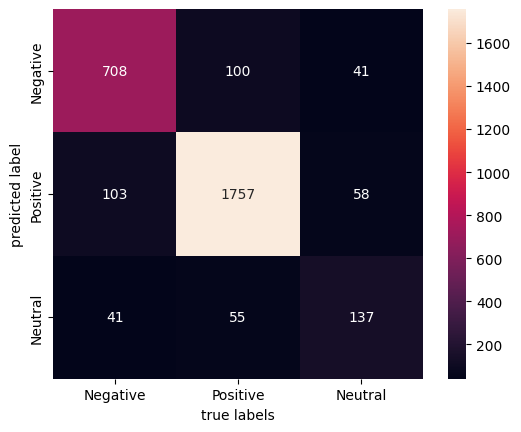

**************************************************
Accuracy: 0.874
Classification report :
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85       852
     Neutral       0.77      0.24      0.37       236
    Positive       0.88      0.96      0.92      1912

    accuracy                           0.87      3000
   macro avg       0.84      0.69      0.71      3000
weighted avg       0.87      0.87      0.86      3000



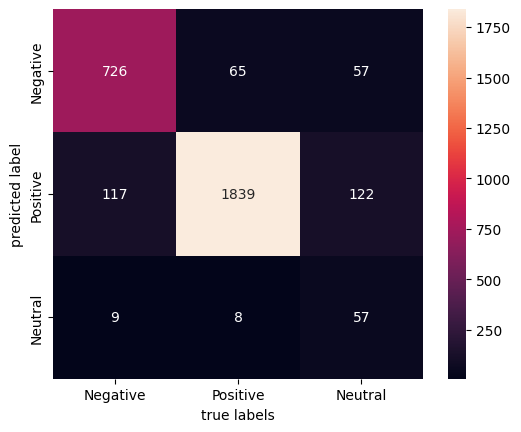

**************************************************


In [47]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model_name = "SVC_1_gram"

dataframe_bow = simple_logistic_classify(model, f'{model_name}_{BOW_METHOD_STRING}', X_tr_bow, y_tr, X_te_bow, y_te, BOW_METHOD_STRING)
dataframe_tfidf_transformer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_TRANSFORMER_METHOD_STRING}', X_tr_tfidf, y_tr, X_te_tfidf, y_te, TF_IDF_TRANSFORMER_METHOD_STRING)
dataframe_tfidf_vectorizer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_VECTORIZER_METHOD_STRING}', X_tfidf_tr, y_tr, X_tfidf_te, y_te, TF_IDF_VECTORIZER_METHOD_STRING)

data_table_svc_1_gram = pd.concat([dataframe_bow, dataframe_tfidf_transformer, dataframe_tfidf_vectorizer], ignore_index=True)

In [ ]:
data_table_1_gram = pd.concat([data_table_logistic_regression_1_gram, data_table_naive_bayes_1_gram, data_table_rfc_1_gram,data_table_svc_1_gram], ignore_index=True)
data_table_1_gram

,model,accuracy
0,LogisticRegression_1_gram_bow,0.878333
1,LogisticRegression_1_gram_tf-idf-transformer,0.883667
2,LogisticRegression_1_gram_tf-idf-vectorizer,0.854333
3,MultinomialNB_1_gram_bow,0.844667
4,MultinomialNB_1_gram_tf-idf-transformer,0.827000
5,MultinomialNB_1_gram_tf-idf-vectorizer,0.799333
6,SVC_1_gram_bow,0.875000
7,SVC_1_gram_tf-idf-transformer,0.867333
8,SVC_1_gram_tf-idf-vectorizer,0.874000
9,RandomForestClassifier_1_gram_bow,0.897000


#### Reprezentacije sa 3-gramima

##### Reprezentacija 3-grama pomoću Bag of Words transformacije

In [52]:
bow_vectorizer = CountVectorizer(tokenizer=lambda doc: doc.split(), ngram_range=(3,3), lowercase=False)
X = bow_vectorizer.fit_transform(training_data['CleanReviews'][:5]) 
pd.DataFrame(X.toarray(), columns=bow_vectorizer.get_feature_names_out())

/home/nastasija/Desktop/DeepLearning/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



,allow secure fit,around pant pocket,arrive work expect,average guy large,base shaky battery,battery hold charge,battery life good,battery life power,battery regularly doesnt,bounce around pant,...,use w one,user cell data,w one hand,w thumb small,well except battery,well lose power,work great arrive,work much longer,work well except,yes calibrate battery
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,1,1,0,1,0,0,1,0,0,1,...,1,1,1,1,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,1,0,1,1,0,...,0,0,0,0,1,1,0,1,1,1


##### Reprezentacija 3-grama korišćenjem TF-IDF transformacije nad rezultatima Bag of Words transformacije

In [53]:
tfidf_transform = TfidfTransformer(norm=None)
X = tfidf_transform.fit_transform(X)
pd.DataFrame(X.toarray(), columns=bow_vectorizer.get_feature_names_out())

,allow secure fit,around pant pocket,arrive work expect,average guy large,base shaky battery,battery hold charge,battery life good,battery life power,battery regularly doesnt,bounce around pant,...,use w one,user cell data,w one hand,w thumb small,well except battery,well lose power,work great arrive,work much longer,work well except,yes calibrate battery
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.098612,0.000000,0.000000,0.000000
1,2.098612,2.098612,0.000000,2.098612,0.000000,0.000000,2.098612,0.000000,0.000000,2.098612,...,2.098612,2.098612,2.098612,2.098612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,2.098612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,2.098612,2.098612,0.000000,2.098612,2.098612,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.098612,2.098612,0.000000,2.098612,2.098612,2.098612


##### Reprezentacija 3-grama pomoću TfIdfVectorizer-a bez korišćenja IDF dela

In [54]:
vectorizer = TfidfVectorizer(use_idf=False, tokenizer=lambda doc: doc.split(), ngram_range=(3,3)) 
X = vectorizer.fit_transform(training_data['CleanReviews'][:5]) 
df = pd.DataFrame(np.round(X.toarray(),3), columns=vectorizer.get_feature_names_out())
df

/home/nastasija/Desktop/DeepLearning/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



,allow secure fit,around pant pocket,arrive work expect,average guy large,base shaky battery,battery hold charge,battery life good,battery life power,battery regularly doesnt,bounce around pant,...,use w one,user cell data,w one hand,w thumb small,well except battery,well lose power,work great arrive,work much longer,work well except,yes calibrate battery
0,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.267,0.000,0.000,0.000
1,0.124,0.124,0.0,0.124,0.000,0.000,0.124,0.000,0.000,0.124,...,0.124,0.124,0.124,0.124,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,1.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.0,0.000,0.171,0.171,0.000,0.171,0.171,0.000,...,0.000,0.000,0.000,0.000,0.171,0.171,0.000,0.171,0.171,0.171


##### Reprezentacija 3-grama pomoću TfIdfVectorizer-a sa uključenim IDF delom

In [56]:
vectorizer = TfidfVectorizer(use_idf=True, tokenizer=lambda doc: doc.split(), ngram_range=(3,3)) 
X = vectorizer.fit_transform(training_data['CleanReviews'][:5]) 
df = pd.DataFrame(np.round(X.toarray(),3), columns=vectorizer.get_feature_names_out())
df

/home/nastasija/Desktop/DeepLearning/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



,allow secure fit,around pant pocket,arrive work expect,average guy large,base shaky battery,battery hold charge,battery life good,battery life power,battery regularly doesnt,bounce around pant,...,use w one,user cell data,w one hand,w thumb small,well except battery,well lose power,work great arrive,work much longer,work well except,yes calibrate battery
0,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.267,0.000,0.000,0.000
1,0.124,0.124,0.0,0.124,0.000,0.000,0.124,0.000,0.000,0.124,...,0.124,0.124,0.124,0.124,0.000,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,1.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.0,0.000,0.171,0.171,0.000,0.171,0.171,0.000,...,0.000,0.000,0.000,0.000,0.171,0.171,0.000,0.171,0.171,0.171


#### Priprema podataka

##### CountVectorizer

In [57]:
bow_transform = CountVectorizer(tokenizer=lambda doc: doc.split(), ngram_range=(3,3), lowercase=False)
X_tr_bow = bow_transform.fit_transform(training_data['CleanReviews'])
y_tr = training_data['Label']

print("Shape of X_tr_bow: ", X_tr_bow.shape)
print("Shape of y_tr: ", y_tr.shape)

print("len(bow_transform.vocabulary_): ", len(bow_transform.vocabulary_))

X_te_bow = bow_transform.transform(test_data['CleanReviews'])
y_te = test_data['Label']

print("Shape of X_te_bow: ", X_te_bow.shape)
print("Shape of y_te: ", y_te.shape)

/home/nastasija/Desktop/DeepLearning/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



Shape of X_tr_bow:  (7000, 90493)
Shape of y_tr:  (7000,)
len(bow_transform.vocabulary_):  90493
Shape of X_te_bow:  (3000, 90493)
Shape of y_te:  (3000,)


##### TfidfTransformer

In [58]:
tfidf_transform = TfidfTransformer(norm=None)
X_tr_tfidf = tfidf_transform.fit_transform(X_tr_bow)
X_te_tfidf = tfidf_transform.transform(X_te_bow)

print("Shape of X_tr_tfidf: ", X_tr_tfidf.shape)
print("Shape of X_te_tfidf: ", X_te_tfidf.shape)

Shape of X_tr_tfidf:  (7000, 90493)
Shape of X_te_tfidf:  (3000, 90493)


##### TfidfVectorizer

In [59]:
tfidf_vectorizer = TfidfVectorizer(use_idf=True, tokenizer=lambda doc: doc.split(), ngram_range=(3,3))
X_tfidf_tr = tfidf_vectorizer.fit_transform(training_data['CleanReviews'])
X_tfidf_te = tfidf_vectorizer.transform(test_data['CleanReviews'])

print("Shape of X_tfidf_tr: ", X_tfidf_tr.shape)
print("Shape of X_tfidf_te: ", X_tfidf_te.shape)

Shape of X_tfidf_tr:  (7000, 90493)
Shape of X_tfidf_te:  (3000, 90493)


##### Klasifikacioni algoritmi koji koriste 3-gram vektorizatore

##### Logistic Regression

Accuracy: 0.7916666666666666
Classification report :
              precision    recall  f1-score   support

    Negative       0.99      0.44      0.61       852
     Neutral       0.99      0.40      0.57       236
    Positive       0.75      1.00      0.86      1912

    accuracy                           0.79      3000
   macro avg       0.91      0.61      0.68      3000
weighted avg       0.84      0.79      0.76      3000



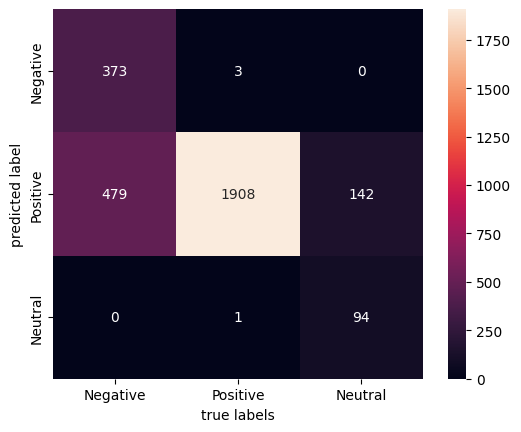

**************************************************
Accuracy: 0.802
Classification report :
              precision    recall  f1-score   support

    Negative       0.98      0.47      0.63       852
     Neutral       0.96      0.44      0.60       236
    Positive       0.77      0.99      0.87      1912

    accuracy                           0.80      3000
   macro avg       0.90      0.64      0.70      3000
weighted avg       0.84      0.80      0.78      3000



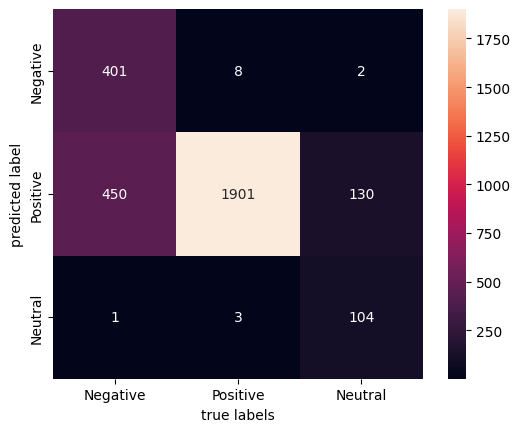

**************************************************
Accuracy: 0.758
Classification report :
              precision    recall  f1-score   support

    Negative       1.00      0.42      0.59       852
     Neutral       1.00      0.02      0.04       236
    Positive       0.72      1.00      0.84      1912

    accuracy                           0.76      3000
   macro avg       0.91      0.48      0.49      3000
weighted avg       0.82      0.76      0.71      3000



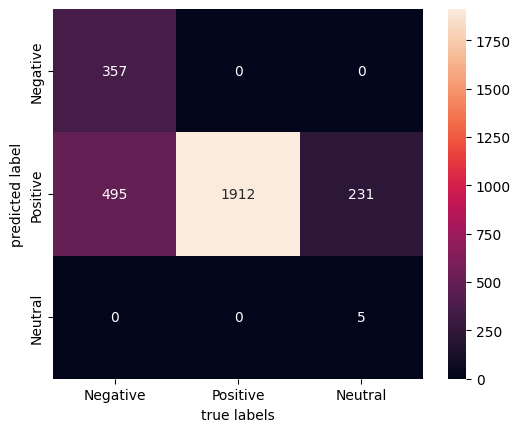

**************************************************


In [60]:
model_name = "LogisticRegression_3_gram"
model = LogisticRegression(max_iter=500)

dataframe_bow = simple_logistic_classify(model, f'{model_name}_{BOW_METHOD_STRING}', X_tr_bow, y_tr, X_te_bow, y_te, BOW_METHOD_STRING)
dataframe_tfidf_transformer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_TRANSFORMER_METHOD_STRING}', X_tr_tfidf, y_tr, X_te_tfidf, y_te, TF_IDF_TRANSFORMER_METHOD_STRING)
dataframe_tfidf_vectorizer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_VECTORIZER_METHOD_STRING}', X_tfidf_tr, y_tr, X_tfidf_te, y_te, TF_IDF_VECTORIZER_METHOD_STRING)

data_table_logistic_regression_3_gram = pd.concat([dataframe_bow, dataframe_tfidf_transformer, dataframe_tfidf_vectorizer], ignore_index=True)

##### Multinomial Naive Bayes

Accuracy: 0.8266666666666667
Classification report :
              precision    recall  f1-score   support

    Negative       0.90      0.60      0.72       852
     Neutral       0.90      0.42      0.58       236
    Positive       0.80      0.98      0.88      1912

    accuracy                           0.83      3000
   macro avg       0.87      0.67      0.73      3000
weighted avg       0.84      0.83      0.81      3000



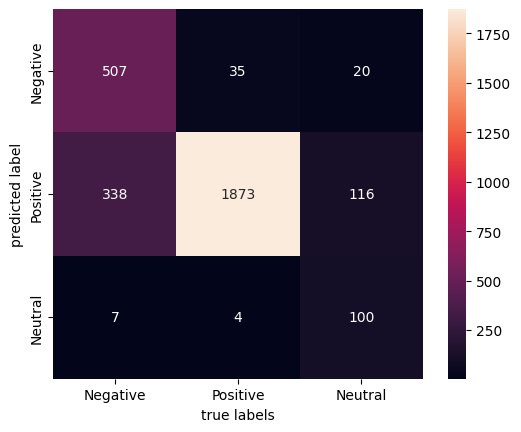

**************************************************
Accuracy: 0.809
Classification report :
              precision    recall  f1-score   support

    Negative       0.86      0.61      0.71       852
     Neutral       0.59      0.51      0.54       236
    Positive       0.82      0.94      0.87      1912

    accuracy                           0.81      3000
   macro avg       0.75      0.68      0.71      3000
weighted avg       0.81      0.81      0.80      3000



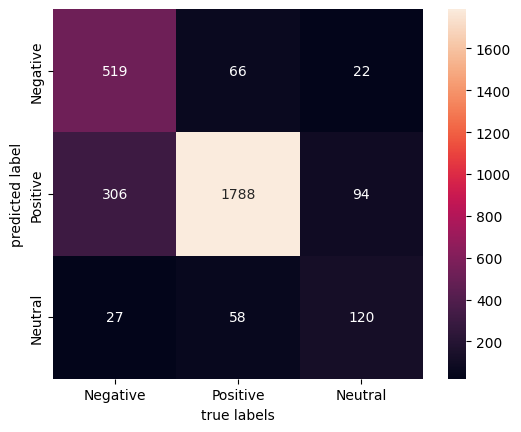

**************************************************
Accuracy: 0.7616666666666667
Classification report :
              precision    recall  f1-score   support

    Negative       1.00      0.42      0.59       852
     Neutral       1.00      0.06      0.11       236
    Positive       0.73      1.00      0.84      1912

    accuracy                           0.76      3000
   macro avg       0.91      0.49      0.52      3000
weighted avg       0.83      0.76      0.71      3000



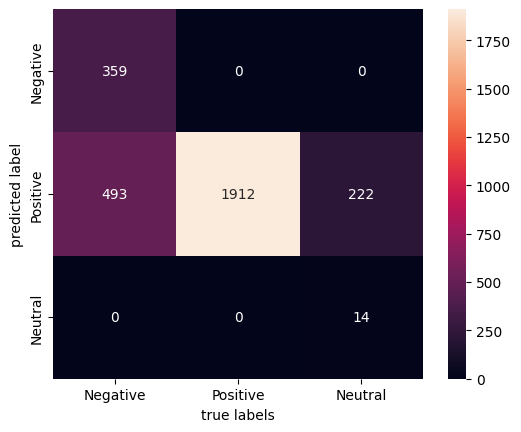

**************************************************


In [61]:
model = MultinomialNB()
model_name = "MultinomialNB_3_gram"

dataframe_bow = simple_logistic_classify(model, f'{model_name}_{BOW_METHOD_STRING}', X_tr_bow, y_tr, X_te_bow, y_te, BOW_METHOD_STRING)
dataframe_tfidf_transformer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_TRANSFORMER_METHOD_STRING}', X_tr_tfidf, y_tr, X_te_tfidf, y_te, TF_IDF_TRANSFORMER_METHOD_STRING)
dataframe_tfidf_vectorizer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_VECTORIZER_METHOD_STRING}', X_tfidf_tr, y_tr, X_tfidf_te, y_te, TF_IDF_VECTORIZER_METHOD_STRING)

data_table_naive_bayes_3_gram = pd.concat([dataframe_bow, dataframe_tfidf_transformer, dataframe_tfidf_vectorizer], ignore_index=True)

##### Random Forest

Accuracy: 0.805
Classification report :
              precision    recall  f1-score   support

    Negative       0.97      0.48      0.64       852
     Neutral       0.97      0.44      0.60       236
    Positive       0.77      0.99      0.87      1912

    accuracy                           0.81      3000
   macro avg       0.90      0.64      0.70      3000
weighted avg       0.84      0.81      0.78      3000



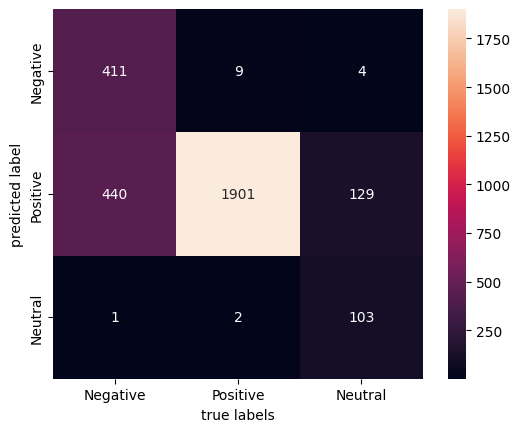

**************************************************
Accuracy: 0.805
Classification report :
              precision    recall  f1-score   support

    Negative       0.97      0.48      0.64       852
     Neutral       0.97      0.44      0.60       236
    Positive       0.77      0.99      0.87      1912

    accuracy                           0.81      3000
   macro avg       0.90      0.64      0.70      3000
weighted avg       0.84      0.81      0.78      3000



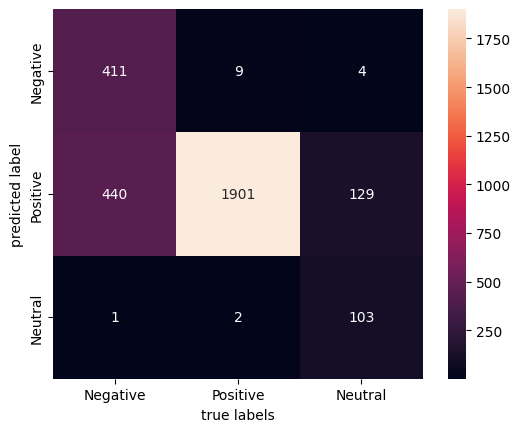

**************************************************
Accuracy: 0.8056666666666666
Classification report :
              precision    recall  f1-score   support

    Negative       0.97      0.49      0.65       852
     Neutral       0.98      0.43      0.60       236
    Positive       0.77      0.99      0.87      1912

    accuracy                           0.81      3000
   macro avg       0.91      0.64      0.71      3000
weighted avg       0.84      0.81      0.78      3000



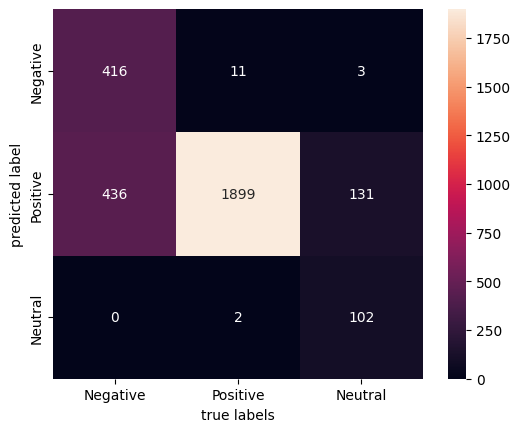

**************************************************


In [62]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model_name = "RandomForestClassifier_3_gram"

dataframe_bow = simple_logistic_classify(model, f'{model_name}_{BOW_METHOD_STRING}', X_tr_bow, y_tr, X_te_bow, y_te, BOW_METHOD_STRING)
dataframe_tfidf_transformer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_TRANSFORMER_METHOD_STRING}', X_tr_tfidf, y_tr, X_te_tfidf, y_te, TF_IDF_TRANSFORMER_METHOD_STRING)
dataframe_tfidf_vectorizer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_VECTORIZER_METHOD_STRING}', X_tfidf_tr, y_tr, X_tfidf_te, y_te, TF_IDF_VECTORIZER_METHOD_STRING)

data_table_rfc_3_gram = pd.concat([dataframe_bow, dataframe_tfidf_transformer, dataframe_tfidf_vectorizer], ignore_index=True)

##### Support Vector Machine

Accuracy: 0.7916666666666666
Classification report :
              precision    recall  f1-score   support

    Negative       0.98      0.44      0.60       852
     Neutral       0.99      0.42      0.59       236
    Positive       0.76      1.00      0.86      1912

    accuracy                           0.79      3000
   macro avg       0.91      0.62      0.69      3000
weighted avg       0.84      0.79      0.77      3000



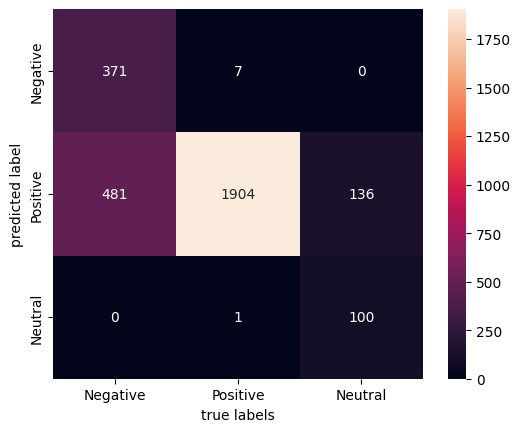

**************************************************
Accuracy: 0.7936666666666666
Classification report :
              precision    recall  f1-score   support

    Negative       0.99      0.44      0.61       852
     Neutral       0.98      0.44      0.60       236
    Positive       0.76      1.00      0.86      1912

    accuracy                           0.79      3000
   macro avg       0.91      0.62      0.69      3000
weighted avg       0.84      0.79      0.77      3000



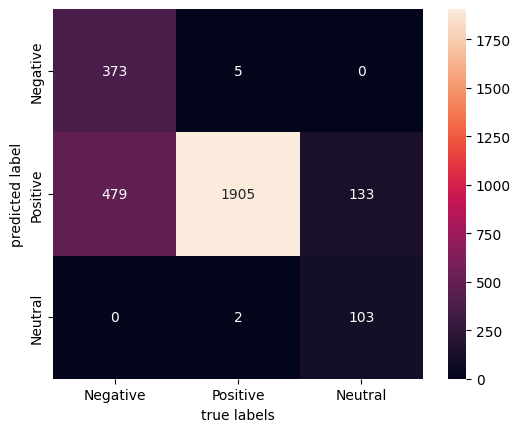

**************************************************
Accuracy: 0.786
Classification report :
              precision    recall  f1-score   support

    Negative       0.98      0.48      0.65       852
     Neutral       0.88      0.18      0.30       236
    Positive       0.75      1.00      0.86      1912

    accuracy                           0.79      3000
   macro avg       0.87      0.55      0.60      3000
weighted avg       0.83      0.79      0.75      3000



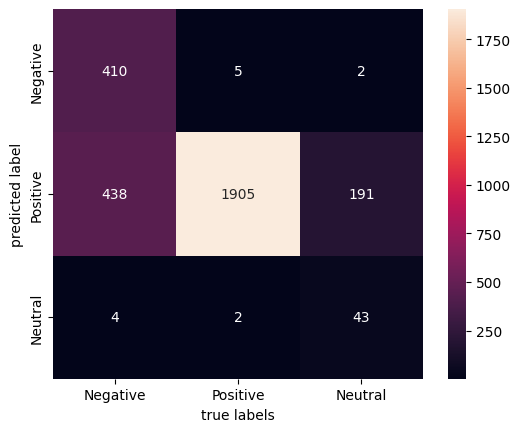

**************************************************


In [64]:
model = SVC(kernel='linear')

model_name = "SVC_3_gram"

dataframe_bow = simple_logistic_classify(model, f'{model_name}_{BOW_METHOD_STRING}', X_tr_bow, y_tr, X_te_bow, y_te, BOW_METHOD_STRING)
dataframe_tfidf_transformer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_TRANSFORMER_METHOD_STRING}', X_tr_tfidf, y_tr, X_te_tfidf, y_te, TF_IDF_TRANSFORMER_METHOD_STRING)
dataframe_tfidf_vectorizer = simple_logistic_classify(model, f'{model_name}_{TF_IDF_VECTORIZER_METHOD_STRING}', X_tfidf_tr, y_tr, X_tfidf_te, y_te, TF_IDF_VECTORIZER_METHOD_STRING)

data_table_svc_3_gram = pd.concat([dataframe_bow, dataframe_tfidf_transformer, dataframe_tfidf_vectorizer], ignore_index=True)

In [66]:
data_table_3_gram = pd.concat([data_table_logistic_regression_3_gram, data_table_naive_bayes_3_gram, data_table_rfc_3_gram,data_table_svc_3_gram], ignore_index=True)
data_table_3_gram

,model,accuracy
0,LogisticRegression_3_gram_bow,0.791667
1,LogisticRegression_3_gram_tf-idf-transformer,0.802000
2,LogisticRegression_3_gram_tf-idf-vectorizer,0.758000
3,MultinomialNB_3_gram_bow,0.826667
4,MultinomialNB_3_gram_tf-idf-transformer,0.809000
5,MultinomialNB_3_gram_tf-idf-vectorizer,0.761667
6,RandomForestClassifier_3_gram_bow,0.805000
7,RandomForestClassifier_3_gram_tf-idf-transformer,0.805000
8,RandomForestClassifier_3_gram_tf-idf-vectorizer,0.805667
9,SVC_3_gram_bow,0.791667


#### Rezultat 

In [68]:
final_dataframe_n_grams = pd.concat([data_table_1_gram, data_table_3_gram ], ignore_index=True)
final_dataframe_n_grams_sorted = final_dataframe_n_grams.sort_values(by="accuracy", ascending=False)
final_dataframe_n_grams_sorted

,model,accuracy
11,RandomForestClassifier_1_gram_tf-idf-vectorizer,0.898333
9,RandomForestClassifier_1_gram_bow,0.897000
10,RandomForestClassifier_1_gram_tf-idf-transformer,0.896667
1,LogisticRegression_1_gram_tf-idf-transformer,0.883667
0,LogisticRegression_1_gram_bow,0.878333
6,SVC_1_gram_bow,0.875000
8,SVC_1_gram_tf-idf-vectorizer,0.874000
7,SVC_1_gram_tf-idf-transformer,0.867333
2,LogisticRegression_1_gram_tf-idf-vectorizer,0.854333
3,MultinomialNB_1_gram_bow,0.844667


#### Treniranje i evaluacija modela zasnovanih na BERT arhitekturi